# Wine Quality — Complete Machine Learning Project

**Goal:** Predict whether a wine is GOOD (quality ≥ 7) or BAD (quality < 7) using its
physicochemical properties, and compare several classification models.

**Steps covered:**
1. Load data & basic exploration (`head`, `info`, `describe`)
2. Missing values & correlation analysis
3. Create binary target `quality_label`
4. Train/test split + Logistic Regression (no scaling)
5. Evaluate (accuracy, precision, recall, F1, confusion matrix)
6. Apply `StandardScaler`, retrain, compare before/after
7. Compare Logistic Regression vs KNN vs Decision Tree
8. Hyperparameter tuning (`GridSearchCV`) on the best model
9. Feature importance analysis


## 1. Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# In Google Colab: upload winequality.csv first, e.g.
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv("winequality.csv")
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Basic Data Analysis
Using `head()`, `info()`, and `describe()` to understand the structure, data types,
and statistical spread of each feature.

In [2]:
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 3. Check for Missing Values

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print("\nTotal missing values:", missing.sum())


Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0


## 4. Correlation Analysis
Correlation of every feature with `quality`, plus a full correlation heatmap.

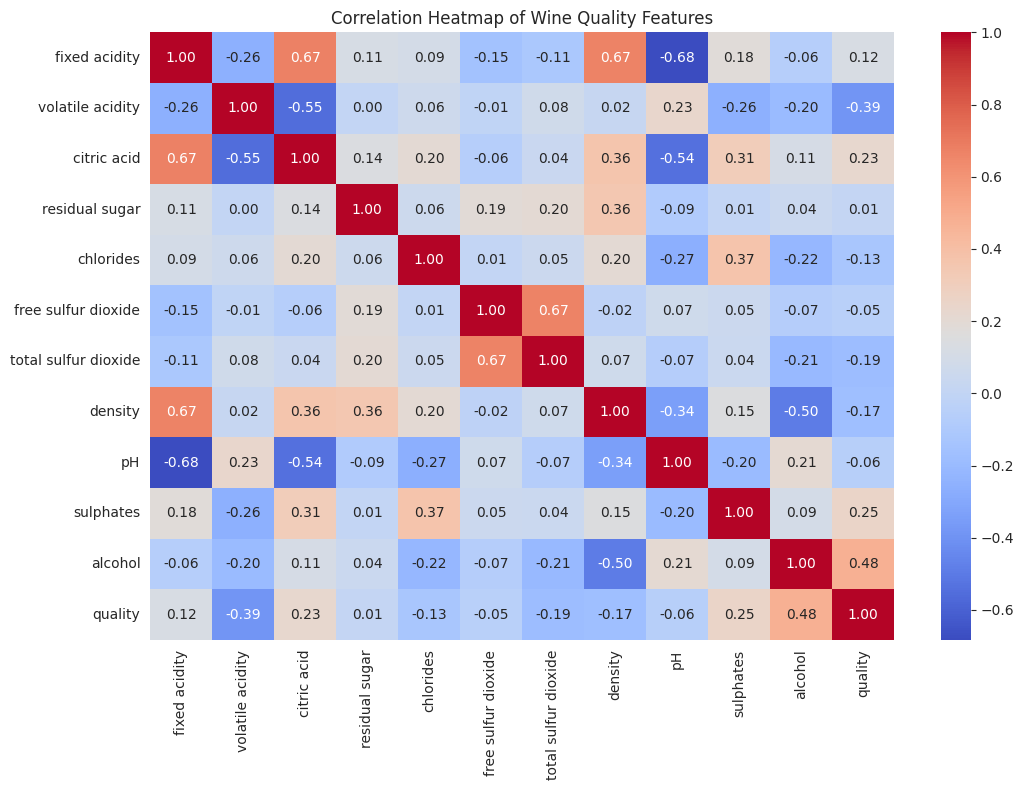

In [6]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Wine Quality Features")
plt.tight_layout()
plt.show()


In [7]:
quality_corr = corr_matrix["quality"].sort_values(ascending=False)
print("Correlation of each feature with 'quality':\n")
print(quality_corr)


Correlation of each feature with 'quality':

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


**Observation:** `alcohol` tends to have the strongest positive correlation with
quality, while `volatile acidity` tends to have the strongest negative correlation.
These are good candidates to watch during feature-importance analysis later.

## 5. Create Binary Target: `quality_label`
- `quality >= 7` → **GOOD (1)**
- `quality < 7`  → **BAD (0)**

quality_label
0    1382
1     217
Name: count, dtype: int64

Class balance (%):
quality_label
0    86.429018
1    13.570982
Name: proportion, dtype: float64


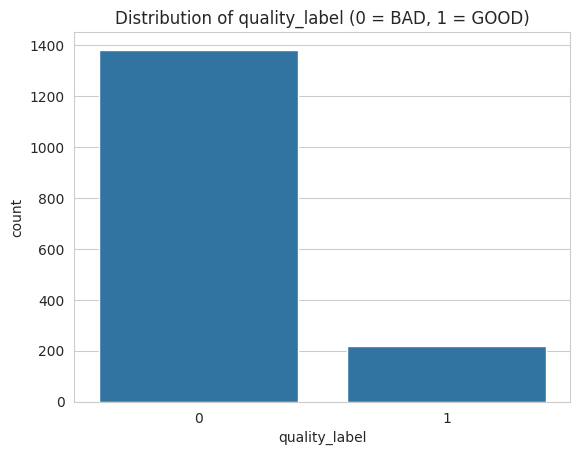

In [8]:
df["quality_label"] = (df["quality"] >= 7).astype(int)

print(df["quality_label"].value_counts())
print("\nClass balance (%):")
print(df["quality_label"].value_counts(normalize=True) * 100)

sns.countplot(x="quality_label", data=df)
plt.title("Distribution of quality_label (0 = BAD, 1 = GOOD)")
plt.xlabel("quality_label")
plt.show()


**Note:** This dataset is imbalanced — GOOD wines are a minority class. Keep this
in mind when interpreting accuracy; precision/recall/F1 matter more here.

## 6. Separate Features and Target

In [9]:
X = df.drop(columns=["quality", "quality_label"])
y = df["quality_label"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.columns.tolist()


Feature matrix shape: (1599, 11)
Target shape: (1599,)


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

## 7. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (1279, 11)  Test size: (320, 11)


## 8. Logistic Regression — WITHOUT Scaling
Baseline model trained directly on raw (unscaled) feature values.

In [11]:
log_reg_unscaled = LogisticRegression(max_iter=5000, random_state=42)
log_reg_unscaled.fit(X_train, y_train)

y_pred_unscaled = log_reg_unscaled.predict(X_test)

def evaluate_model(y_true, y_pred, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"--- {model_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {"model": model_name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1}

results_unscaled = evaluate_model(y_test, y_pred_unscaled, "Logistic Regression (No Scaling)")


--- Logistic Regression (No Scaling) ---


Accuracy : 0.8938
Precision: 0.7368
Recall   : 0.3256
F1-score : 0.4516

Confusion Matrix:
[[272   5]
 [ 29  14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       277
           1       0.74      0.33      0.45        43

    accuracy                           0.89       320
   macro avg       0.82      0.65      0.70       320
weighted avg       0.88      0.89      0.88       320



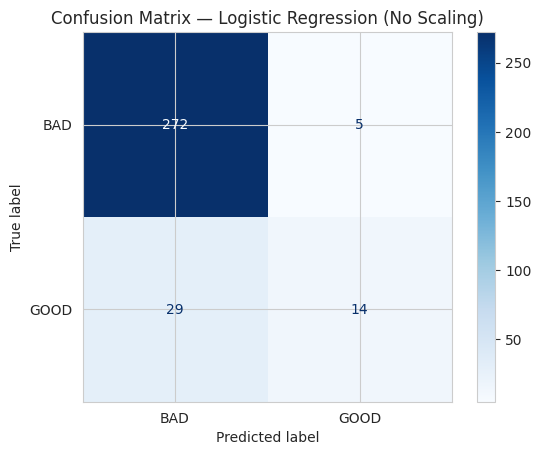

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_unscaled,
                                         display_labels=["BAD", "GOOD"], cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression (No Scaling)")
plt.show()


## 9. Apply StandardScaler and Retrain
Logistic Regression is sensitive to feature scale (it's a gradient-based, distance-influenced
linear model), so scaling often changes convergence speed and sometimes performance.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg_scaled = LogisticRegression(max_iter=5000, random_state=42)
log_reg_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = log_reg_scaled.predict(X_test_scaled)
results_scaled = evaluate_model(y_test, y_pred_scaled, "Logistic Regression (Scaled)")


--- Logistic Regression (Scaled) ---
Accuracy : 0.8938
Precision: 0.6957
Recall   : 0.3721
F1-score : 0.4848

Confusion Matrix:
[[270   7]
 [ 27  16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       277
           1       0.70      0.37      0.48        43

    accuracy                           0.89       320
   macro avg       0.80      0.67      0.71       320
weighted avg       0.88      0.89      0.88       320



In [14]:
comparison_df = pd.DataFrame([results_unscaled, results_scaled]).set_index("model")
comparison_df.round(4)


,accuracy,precision,recall,f1
model,,,,
Logistic Regression (No Scaling),0.8938,0.7368,0.3256,0.4516
Logistic Regression (Scaled),0.8938,0.6957,0.3721,0.4848


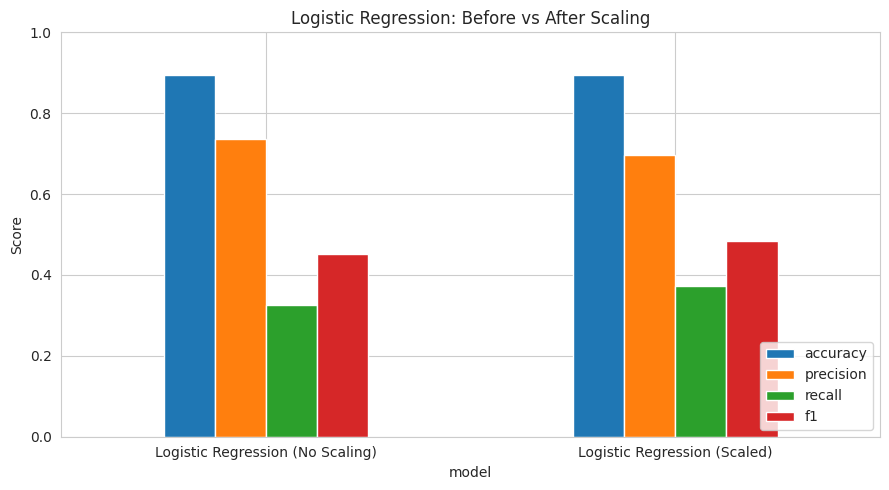

In [15]:
comparison_df[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(9,5))
plt.title("Logistic Regression: Before vs After Scaling")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Observation:** Scaling generally has little to no effect on Logistic Regression's
*predictions* on this dataset (it mainly changes coefficient magnitudes and convergence
speed) — but it becomes essential for distance-based models like KNN, tested next.

## 10. Compare Three Models: Logistic Regression, KNN, Decision Tree
All three are trained on the **scaled** data for a fair, consistent comparison
(scaling doesn't hurt tree-based models and is required for KNN).

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

model_results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    res = evaluate_model(y_test, y_pred, name)
    model_results.append(res)
    print("=" * 60)


--- Logistic Regression ---
Accuracy : 0.8938
Precision: 0.6957
Recall   : 0.3721
F1-score : 0.4848

Confusion Matrix:
[[270   7]
 [ 27  16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       277
           1       0.70      0.37      0.48        43

    accuracy                           0.89       320
   macro avg       0.80      0.67      0.71       320
weighted avg       0.88      0.89      0.88       320

--- KNN ---
Accuracy : 0.8938
Precision: 0.6667
Recall   : 0.4186
F1-score : 0.5143

Confusion Matrix:
[[268   9]
 [ 25  18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       277
           1       0.67      0.42      0.51        43

    accuracy                           0.89       320
   macro avg       0.79      0.69      0.73       320
weighted avg       0.88      0.89      0.88       320

--- Decision Tree ---
Accuracy

In [17]:
model_comparison_df = pd.DataFrame(model_results).set_index("model")
model_comparison_df.round(4)


,accuracy,precision,recall,f1
model,,,,
Logistic Regression,0.8938,0.6957,0.3721,0.4848
KNN,0.8938,0.6667,0.4186,0.5143
Decision Tree,0.9062,0.6383,0.6977,0.6667


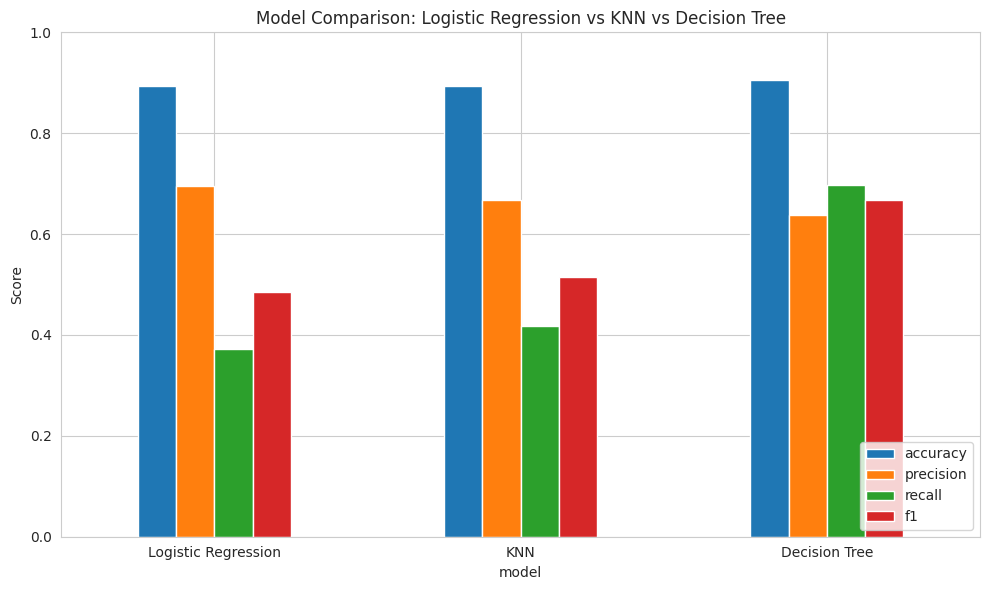

In [18]:
model_comparison_df[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison: Logistic Regression vs KNN vs Decision Tree")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [19]:
best_model_name = model_comparison_df["f1"].idxmax()
print(f"Best model based on F1-score: {best_model_name}")
model_comparison_df.loc[[best_model_name]]


Best model based on F1-score: Decision Tree


,accuracy,precision,recall,f1
model,,,,
Decision Tree,0.90625,0.638298,0.697674,0.666667


**Note:** F1-score is used to pick the "best" model rather than accuracy, since the
dataset is imbalanced (far fewer GOOD wines than BAD). F1 balances precision and recall,
which matters more here than raw accuracy.

## 11. Hyperparameter Tuning with GridSearchCV
Tuning whichever model was selected as best above. The grid below covers the three
candidates so this cell works regardless of which model wins.

In [20]:
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        "weights": ["uniform", "distance"],
        "p": [1, 2]
    },
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "criterion": ["gini", "entropy"]
    }
}

base_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

grid = GridSearchCV(
    base_models[best_model_name],
    param_grids[best_model_name],
    scoring="f1",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print("Best parameters found:", grid.best_params_)
print("Best cross-validated F1-score:", round(grid.best_score_, 4))


Best parameters found: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validated F1-score: 0.5274


In [21]:
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

results_tuned = evaluate_model(y_test, y_pred_tuned, f"{best_model_name} (Tuned)")


--- Decision Tree (Tuned) ---
Accuracy : 0.9250
Precision: 0.7317
Recall   : 0.6977
F1-score : 0.7143

Confusion Matrix:
[[266  11]
 [ 13  30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       277
           1       0.73      0.70      0.71        43

    accuracy                           0.93       320
   macro avg       0.84      0.83      0.84       320
weighted avg       0.92      0.93      0.92       320



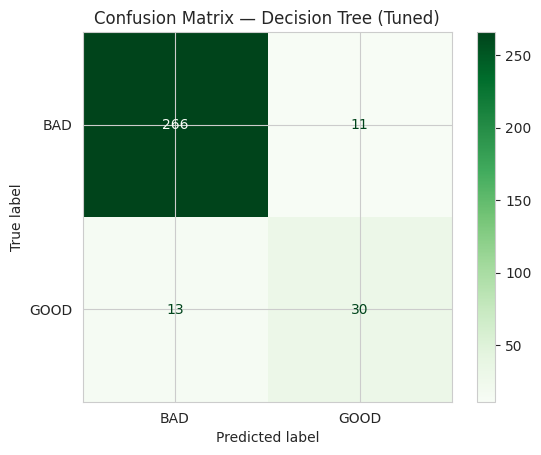

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned,
                                         display_labels=["BAD", "GOOD"], cmap="Greens")
plt.title(f"Confusion Matrix — {best_model_name} (Tuned)")
plt.show()


In [23]:
final_comparison = pd.DataFrame(
    model_results + [results_tuned]
).set_index("model")
final_comparison.round(4)


,accuracy,precision,recall,f1
model,,,,
Logistic Regression,0.8938,0.6957,0.3721,0.4848
KNN,0.8938,0.6667,0.4186,0.5143
Decision Tree,0.9062,0.6383,0.6977,0.6667
Decision Tree (Tuned),0.9250,0.7317,0.6977,0.7143


**Before vs after tuning, all models side by side:**

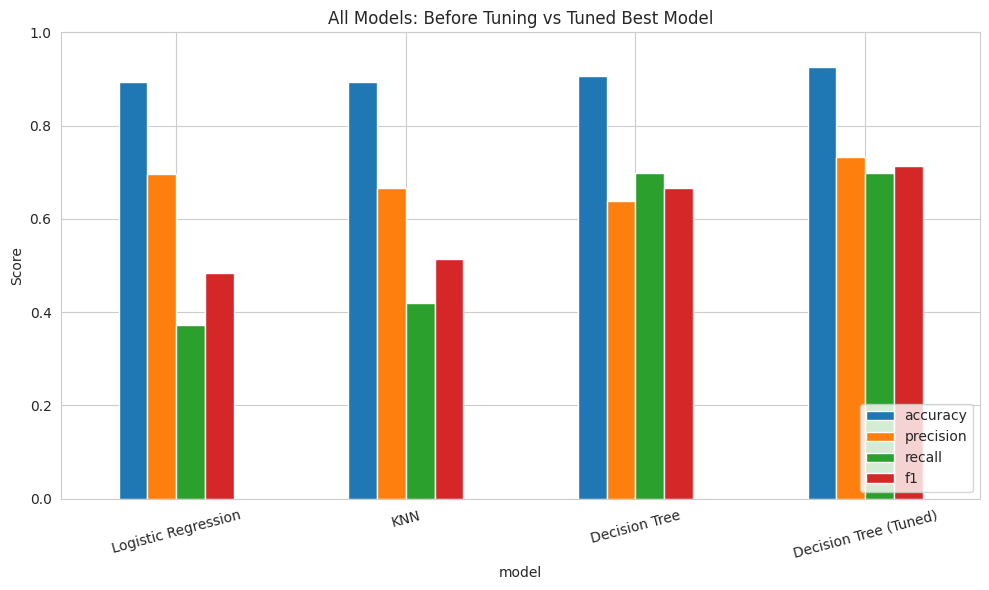

In [24]:
final_comparison[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(10,6))
plt.title("All Models: Before Tuning vs Tuned Best Model")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 12. Feature Importance Analysis
Which physicochemical properties matter most for predicting wine quality?
- **Decision Tree** → built-in `feature_importances_`
- **Logistic Regression** → absolute value of standardized coefficients
- **KNN** → has no native importances, so a Decision Tree is fit as a reference
  to show importance in that case.

In [25]:
if best_model_name == "Decision Tree":
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
elif best_model_name == "Logistic Regression":
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)
else:  # KNN has no native importances -> use a Decision Tree as a reference model
    ref_tree = DecisionTreeClassifier(random_state=42)
    ref_tree.fit(X_train_scaled, y_train)
    importances = pd.Series(ref_tree.feature_importances_, index=X.columns)
    print("KNN has no built-in feature importances; showing a reference Decision Tree's importances instead.")

importances = importances.sort_values(ascending=False)
print(importances)


alcohol                 0.285914
sulphates               0.101674
volatile acidity        0.097330
pH                      0.086588
total sulfur dioxide    0.078875
chlorides               0.071724
residual sugar          0.071398
citric acid             0.061351
free sulfur dioxide     0.058129
density                 0.053257
fixed acidity           0.033761
dtype: float64


/tmp/ipykernel_582/3052628278.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


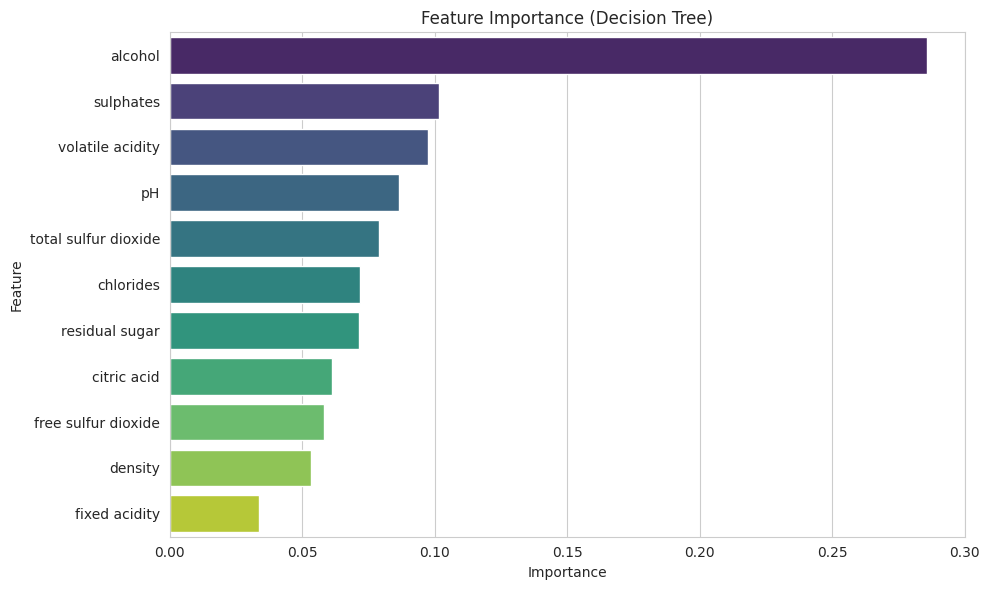

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title(f"Feature Importance ({best_model_name})")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Summary

- Built a binary classifier (`quality_label`) from the wine quality dataset.
- Compared Logistic Regression performance before and after `StandardScaler`.
- Compared Logistic Regression, KNN, and Decision Tree using accuracy, precision,
  recall, and F1-score.
- Tuned the strongest model with `GridSearchCV` and evaluated the tuned version.
- Identified which features most influence wine quality predictions.

Re-run this notebook end-to-end in Colab (`Runtime → Run all`) after uploading
`winequality.csv` — every cell above will regenerate its own output.